# Predicting Insurance Enrollment

This notebook builds an end-to-end ML pipeline to predict whether an employee enrolls in a voluntary insurance product.

## 1) Imports and Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2) Load Data

In [2]:
data_path = 'employee_data.csv'
df = pd.read_csv(data_path)

print('Shape:', df.shape)
display(df.head())

Shape: (10000, 10)


,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled
0,10001,60,Female,Single,55122.97,Part-time,West,No,1.5,0
1,10002,50,Female,Single,89549.66,Full-time,West,Yes,12.8,1
2,10003,36,Male,Divorced,74145.66,Part-time,Midwest,No,3.8,0
3,10004,64,Female,Married,53877.83,Full-time,Northeast,No,3.3,0
4,10005,29,Male,Single,63404.63,Contract,Midwest,Yes,10.0,0


## 3) Quick Data Quality Checks

In [3]:
print('Column types:')
display(df.dtypes.to_frame('dtype'))

print('Missing values by column:')
display(df.isna().sum().to_frame('missing_count'))

print('Target balance:')
target_dist = df['enrolled'].value_counts(normalize=True).rename('proportion')
display(target_dist)

Column types:


,dtype
employee_id,int64
age,int64
gender,object
marital_status,object
salary,float64
employment_type,object
region,object
has_dependents,object
tenure_years,float64
enrolled,int64


Missing values by column:


,missing_count
employee_id,0
age,0
gender,0
marital_status,0
salary,0
employment_type,0
region,0
has_dependents,0
tenure_years,0
enrolled,0


Target balance:


enrolled
1    0.6174
0    0.3826
Name: proportion, dtype: float64

## Observation
- Target Variable (Enrollment): ~61.7% enrolled vs 38.3% not enrolled. Slight class imbalance, but not severe
- No urgent need for resampling (SMOTE, etc.)
    

## 4) Exploratory Data Analysis

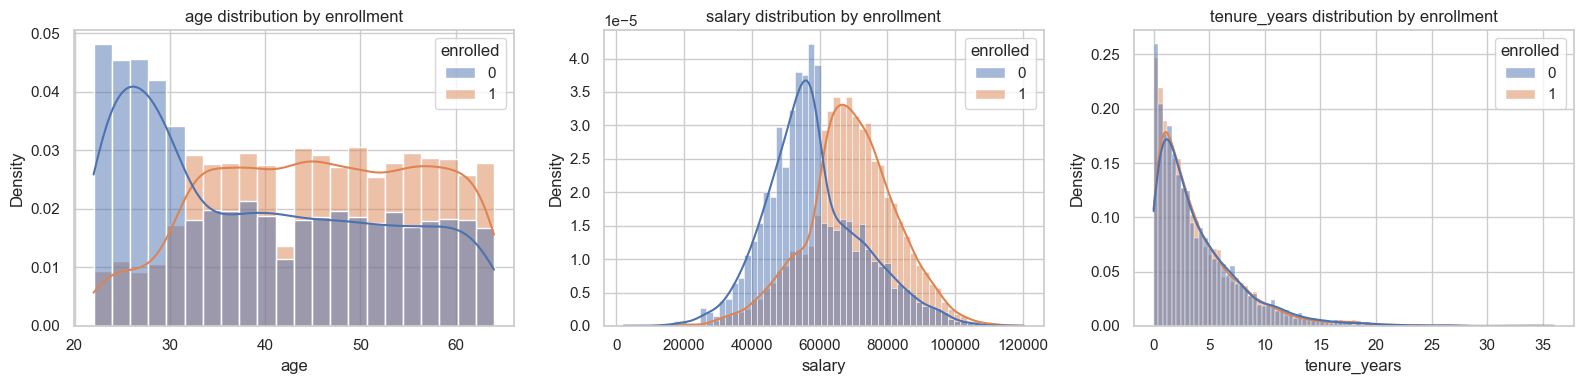

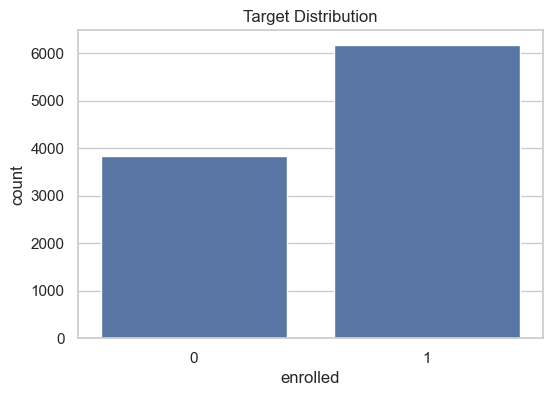

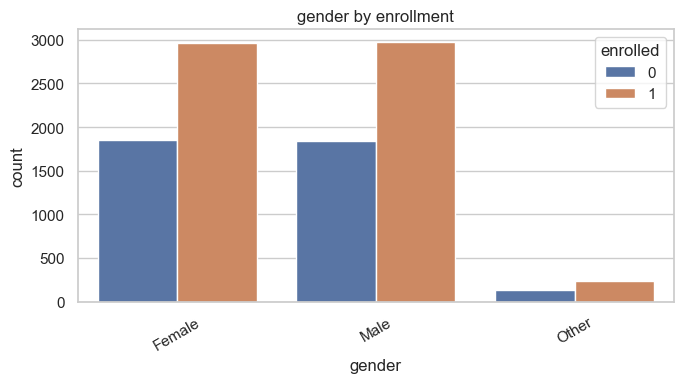

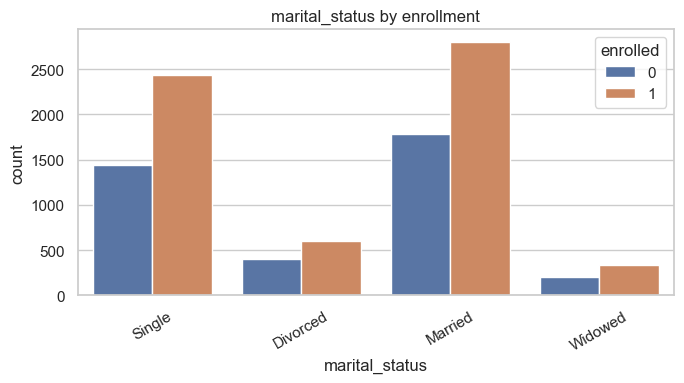

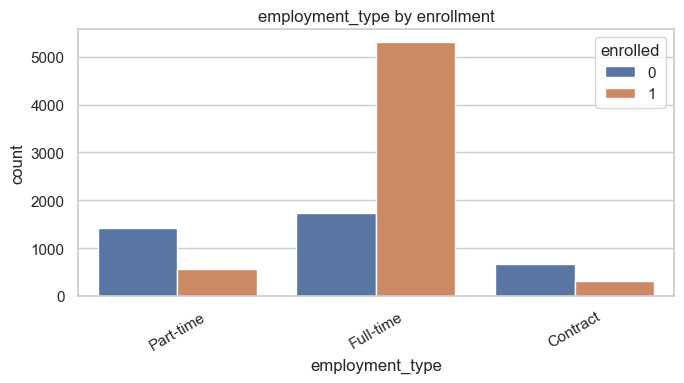

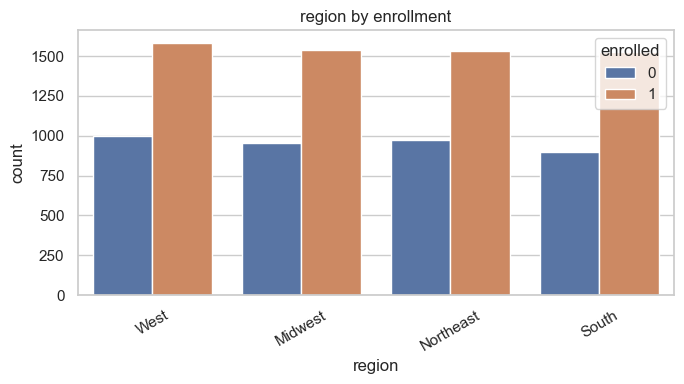

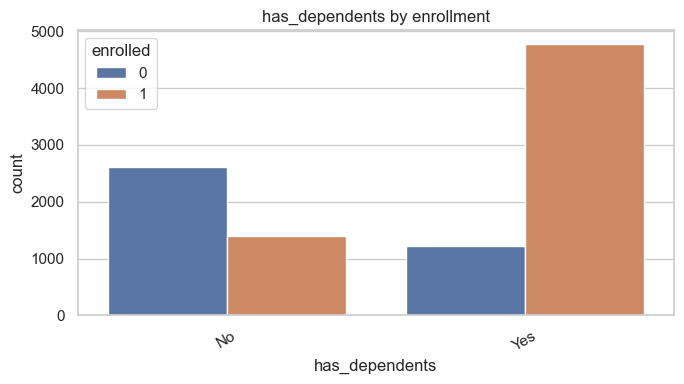

In [14]:
numeric_cols = ['age', 'salary', 'tenure_years']
categorical_cols = ['gender', 'marital_status', 'employment_type', 'region', 'has_dependents']

# Numeric distributions with KDE by target
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df,
        x=col,
        hue='enrolled',        # 🔥 split by target
        kde=True,
        stat='density',        # better comparison
        common_norm=False,     # separate normalization
        ax=axes[i]
    )
    axes[i].set_title(f'{col} distribution by enrollment')

plt.tight_layout()
plt.show()

# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='enrolled')
plt.title('Target Distribution')
plt.show()

# Categorical plots
for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, hue='enrolled')
    plt.title(f'{col} by enrollment')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Based on the exploratory grap it seems:

Strong predictors:

1. employment_type
2. has_dependents
3. marital_status
4. age
5. salary

Moderate and Weak:

1. tenure_years
2. gender
3. region

## Feature Engineering

<Axes: xlabel='tenure_log', ylabel='Count'>

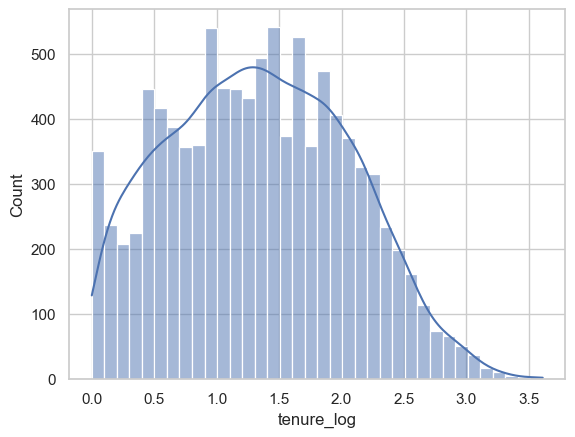

In [13]:
### Feature Engineering

df['tenure_log'] = np.log1p(df['tenure_years'])
sns.histplot(df['tenure_log'], kde=True)

In [15]:
df['age_group'] = pd.cut(df['age'],
                        bins=[20,30,40,50,60,70],
                        labels=['20s','30s','40s','50s','60+'])
df['salary_band'] = pd.qcut(df['salary'], q=4, labels=['Low','Mid','High','Very High'])
df.head()

,employee_id,age,gender,marital_status,salary,employment_type,region,has_dependents,tenure_years,enrolled,tenure_log,age_group,salary_band
0,10001,60,Female,Single,55122.97,Part-time,West,No,1.5,0,0.916291,50s,Mid
1,10002,50,Female,Single,89549.66,Full-time,West,Yes,12.8,1,2.624669,40s,Very High
2,10003,36,Male,Divorced,74145.66,Part-time,Midwest,No,3.8,0,1.568616,30s,High
3,10004,64,Female,Married,53877.83,Full-time,Northeast,No,3.3,0,1.458615,60+,Low
4,10005,29,Male,Single,63404.63,Contract,Midwest,Yes,10.0,0,2.397895,20s,Mid


## 6) Train/Test Split and Preprocessing

In [24]:
X = df.drop(columns=['enrolled'])
y = df['enrolled']

numeric_features = ['tenure_years']
categorical_features = ['gender', 'marital_status', 'employment_type', 'region', 'has_dependents','age_group','salary_band']
identifier_features = ['employee_id']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features),
        ('id', 'drop', identifier_features),
    ]
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (8000, 12)
Test shape: (2000, 12)


## 7) Model Training and Comparison

In [25]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight='balanced_subsample'
    ),
}

results = {}
fitted_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results[model_name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }
    fitted_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).T.sort_values(by=['roc_auc', 'f1'], ascending=False)
display(results_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']])

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.946,0.997352,0.91498,0.954392,0.994342
Random Forest,0.9465,0.974747,0.937652,0.95584,0.994071


## 8) Final Model Evaluation

Best model: Logistic Regression
Classification report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       765
           1       1.00      0.91      0.95      1235

    accuracy                           0.95      2000
   macro avg       0.94      0.96      0.94      2000
weighted avg       0.95      0.95      0.95      2000



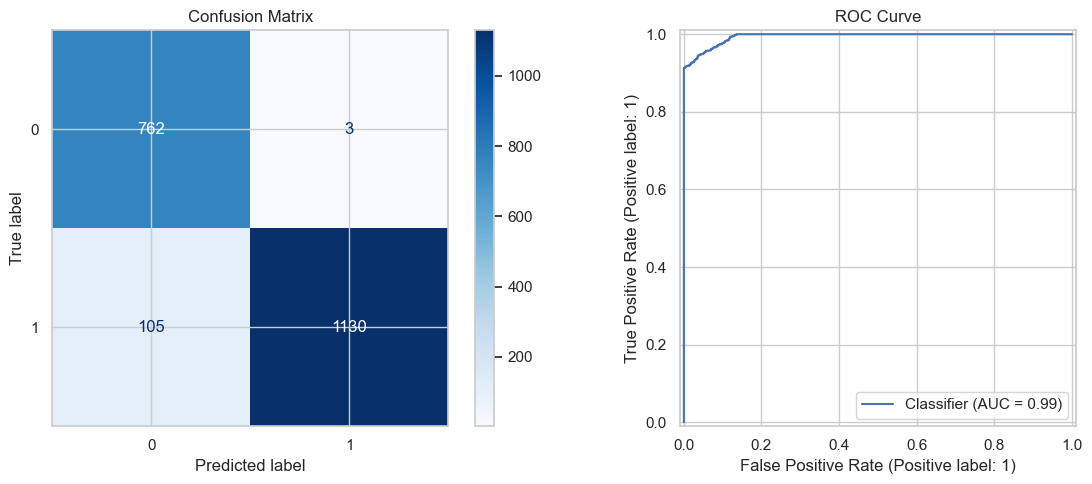

In [26]:
best_model_name = results_df.index[0]
best_pipeline = fitted_pipelines[best_model_name]

y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

print('Best model:', best_model_name)
print('Classification report:')
print(classification_report(y_test, y_pred_best))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_proba_best, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()

## 9) Model Interpretability Snapshot

Top absolute coefficients:


,coefficient
cat__age_group_20s,-7.368620
cat__employment_type_Full-time,5.736960
cat__salary_band_Low,-5.697843
cat__has_dependents_No,-4.822215
cat__has_dependents_Yes,4.090602
cat__salary_band_Very High,3.337325
cat__employment_type_Contract,-3.314544
cat__salary_band_High,3.284103
cat__employment_type_Part-time,-3.154028
cat__age_group_50s,1.816223


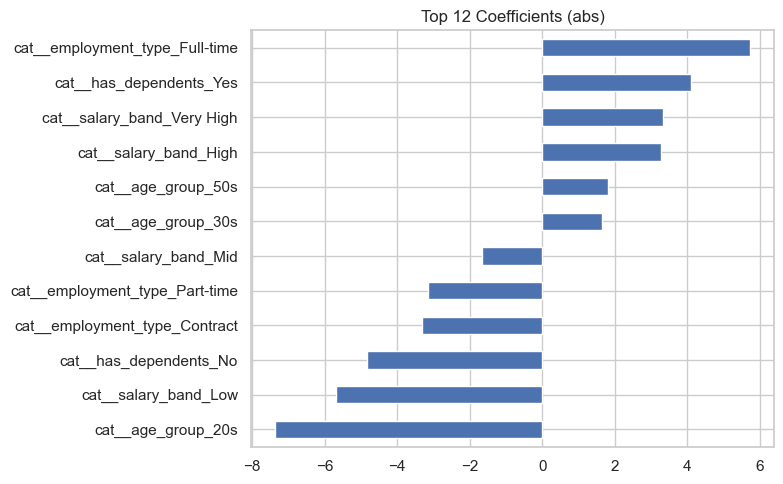

In [27]:
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
model_fitted = best_pipeline.named_steps['model']

feature_names = preprocessor_fitted.get_feature_names_out()

if hasattr(model_fitted, 'feature_importances_'):
    importance = pd.Series(model_fitted.feature_importances_, index=feature_names).sort_values(ascending=False).head(12)
    print('Top feature importances:')
    display(importance.to_frame('importance'))
    importance.sort_values().plot(kind='barh', figsize=(8, 5), title='Top 12 Feature Importances')
    plt.tight_layout()
    plt.show()
else:
    coef = pd.Series(model_fitted.coef_[0], index=feature_names)
    top = coef.reindex(coef.abs().sort_values(ascending=False).head(12).index)
    print('Top absolute coefficients:')
    display(top.to_frame('coefficient'))
    top.sort_values().plot(kind='barh', figsize=(8, 5), title='Top 12 Coefficients (abs)')
    plt.tight_layout()
    plt.show()

# 📄 Employee Enrollment Prediction – Final Report

## 1. Data Observations

- The dataset is **clean and complete**, with no missing values and well-defined feature types.
- The target variable (`enrolled`) is **moderately balanced** (~62% enrolled vs ~38% not enrolled), so no heavy resampling was required.
- Strong patterns exist in the data:
  - **Employment type** is a major driver — full-time employees are significantly more likely to enroll.
  - **Dependents** strongly influence enrollment — employees with dependents show much higher participation.
  - **Salary bands** show a clear trend — higher salary groups have higher enrollment rates.
  - **Age groups** indicate increasing enrollment likelihood with age.
- Some features such as **region and gender** show minimal variation with respect to the target and are weaker predictors.
- Binning (`age_group`, `salary_band`) helped capture **non-linear relationships** effectively.

---

## 2. Model Choices & Rationale

Two models were selected:

### Logistic Regression
- Chosen for:
  - Interpretability
  - Strong baseline for binary classification
  - Ability to understand feature impact via coefficients
- Works well with one-hot encoded categorical variables

### Random Forest
- Chosen for:
  - Capturing non-linear relationships
  - Handling feature interactions automatically
  - Robustness to noise and feature scaling

👉 Both models were integrated into a **scikit-learn pipeline** with:
- Separate preprocessing for numeric and categorical features
- One-hot encoding for categorical variables
- Standardization for numeric variables

---

## 3. Evaluation Results

| Model                | Accuracy | Precision | Recall | F1 Score | ROC AUC |
|---------------------|---------|----------|--------|---------|---------|
| Logistic Regression | 0.946   | 0.997    | 0.915  | 0.954   | 0.994   |
| Random Forest       | 0.9465  | 0.975    | 0.938  | 0.956   | 0.994   |

### Key Observations:
- Both models performed **extremely well**, indicating strong signal in the data.
- **Random Forest achieved slightly higher F1-score**, while Logistic Regression had higher precision.
- ROC-AUC (~0.994) for both models indicates **excellent separability** between classes.

### Final Selection:
- **Logistic Regression was selected as the final model**
  - Comparable performance
  - Higher interpretability
  - Easier to explain to business stakeholders

---

## 4. Feature Insights

From model coefficients:

### Strong Positive Drivers (increase enrollment likelihood):
- Full-time employment
- Having dependents
- High and very high salary bands
- Older age groups (30s, 50s)

### Strong Negative Drivers:
- Age in 20s
- Low salary band
- Part-time and contract employment
- No dependents

👉 These align well with intuitive business logic.

---

## 5. Key Takeaways

- Enrollment is strongly influenced by **financial stability and life stage factors**
- Employees who are:
  - Full-time
  - Higher earning
  - Older
  - Have dependents  
  are significantly more likely to enroll
- The problem is **highly predictable**, suggesting structured patterns in the data

---

## 6. What I Would Do Next (With More Time)

### Model Improvements
- Perform **hyperparameter tuning** (GridSearch / Optuna)
- Try advanced models:
  - XGBoost / LightGBM

### Feature Engineering
- Create **interaction features** (e.g., salary × employment type)
- Explore **target encoding** for categorical variables

### Validation & Robustness
- Perform **cross-validation**
- Test on **out-of-time or external data**

### Business Impact
- Build a **probability-based segmentation**:
  - High likelihood → target campaigns
  - Medium → nurture strategies
  - Low → deprioritize

### Deployment
- Wrap model into an API for real-time predictions
- Monitor model drift and performance over time

---